In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import astropy.constants as const
import astropy.units as u
from set_rcParams import set_rcParams, set_tick_font
from scipy.constants import k
from sklearn.linear_model import LinearRegression
from scipy.special import gamma, factorial
from scipy import stats
# print(plt.rcParams.keys())
import glob
set_rcParams(presentation=True)

In [2]:
T_a0 = 600 * u.K
T_b0 = 100 * u.K
m = 6.646764e-27 * u.kg
n = 1e20 * u.m**-3
sigma = 1e-18 * u.m**2

def mean_free_path(n, sigma):
  return (1 / (np.sqrt(2) * n * sigma)).to(u.m)

def mean_relative_vel(m_1, T_1, m_2, T_2):
  return (np.sqrt(8 / np.pi) * np.sqrt(const.k_B * T_1 / m_1 + const.k_B * T_2 / m_2)).to(u.m /u.s)


v_rel_mean = mean_relative_vel(m, T_a0, m, T_b0)
mean_free_path = 1 / (n * sigma)
mean_collision_frequency = n * sigma * v_rel_mean

print(v_rel_mean)
print(mean_free_path)
print(1 / mean_collision_frequency)

1924.2238311510919 m / s
0.009999999999999998 m
5.196900609020048e-06 s


In [3]:
# mean speed of the distribution
def v_mean(T,m):
  return 2 / np.sqrt(np.pi) * np.sqrt( 2 * const.R * T / (m * const.N_A) )

def v_rel_mean(T, m):
  return np.sqrt(2) * v_mean

In [4]:
T_a0 = 600 * u.K
T_b0 = 500 * u.K
density = 3e23 * u.m**-3
mass =  6.6464764e-27 * u.kg
mean_sigma_g_inter = 1e-20 * u.m**3 / u.s
mean_sigma_g_intra = 100 * mean_sigma_g_inter

nu_col_inter = density * mean_sigma_g_inter
nu_col_intra = density * mean_sigma_g_intra
print(nu_col_inter)
print(nu_col_intra)
v_mean_alpha = v_mean(T_a0, mass).to(u.m / u.s, equivalencies=u.temperature_energy)
v_mean_beta = v_mean(T_b0, mass).to(u.m / u.s, equivalencies=u.temperature_energy)

lambda_alpha_inter = v_mean_alpha / nu_col_inter
lambda_alpha_intra = v_mean_alpha / nu_col_intra
lambda_beta_intra = v_mean_beta / nu_col_intra
lambda_beta_inter = v_mean_beta / nu_col_inter

print(lambda_alpha_inter)
print(lambda_alpha_intra)
print()
print(lambda_beta_inter)
print(lambda_beta_intra)

dt = min([1 / nu_col_inter, 1 / nu_col_intra]) / 3
rho = min([lambda_alpha_inter, lambda_alpha_intra, lambda_beta_inter, lambda_beta_intra]) / 4
domain_lenth = 4 * rho * 2
print()
print(f"Time Step      : {dt:0.4E}")
print(f"Element Radius : {rho:0.4E}")
print(f"Domain Length : {domain_lenth:0.4E}")

3000.0 1 / s
300000.0 1 / s
0.5938412140959309 m
0.00593841214095931 m

0.5421003808943269 m
0.005421003808943269 m

Time Step      : 1.1111E-06 s
Element Radius : 1.3553E-03 m
Domain Length : 1.0842E-02 m


In [5]:
elem_size_lenth = 2e-2 / 4
elem_radius = elem_size_lenth / 2

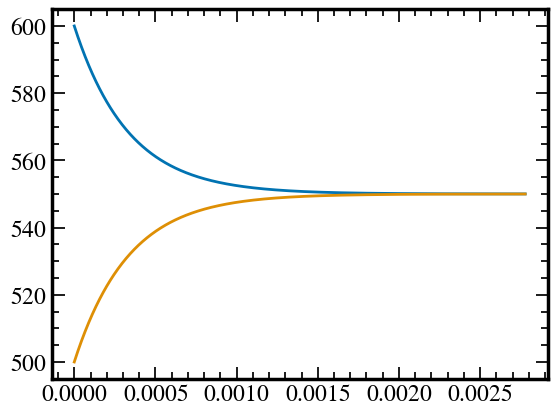

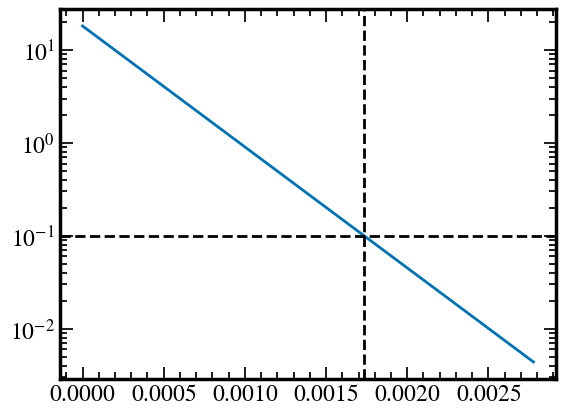

1561.5615615615613


In [6]:
def T_alpha_true(t, T_a=T_a0, T_b=T_b0, inter_nu=nu_col_inter.value):
  return (T_a + T_b) / 2 + (T_a - T_b) / 2 * np.exp(-inter_nu * t)

def T_beta_true(t, T_a=T_a0, T_b=T_b0, inter_nu=nu_col_inter.value):
  return (T_a + T_b) / 2 - (T_a - T_b) / 2 * np.exp(-inter_nu * t)

t_range = np.linspace(0, dt.value * 2500, 1000)
T_a = T_alpha_true(t_range)
T_b = T_beta_true(t_range)
plt.figure()
plt.plot(t_range, T_a)
plt.plot(t_range, T_b)
plt.show()

error = 100 * (T_a - T_b) / ((T_a0 + T_b0) / 2)
t_equilib = t_range[np.where(error <= 1e-1)[0][0]]
plt.figure()
plt.semilogy(t_range, error)
plt.axhline(1e-1, c='k', linestyle='--')
plt.axvline(t_equilib, c='k', linestyle='--')
plt.show()

num_steps = t_equilib / dt.value
print(num_steps)

In [7]:
# C = 0.1
# T_a = 1
# T_b_range = np.linspace(0, 1, 1000)
# t_range = np.linspace(0, 100, 1000)
# error = 2 * (T_a - T_b_range) / (T_a + T_b_range) * 100

# plt.figure()
# plt.plot(T_b_range, error)
# plt.ylabel("$\\frac{T_\\alpha - T_\\beta}{T_\\text{equib}} \\times 100$")
# plt.xlabel("$T_\\beta / T_\\alpha$")
# plt.show()

In [8]:
# def collect_initial_data(N_p, M):
#     files = glob.glob(f"{N_p:d}_ppe/run_*_T_beta*.csv")
#     all_data = pd.DataFrame()
#     for i, f in enumerate(files):
#         all_data = pd.concat((all_data, pd.read_csv(f)), ignore_index=True)

#     all_data.to_csv(f"initialization_beta/{N_p:d}_ppe.csv")
#     return all_data


# for i in range(4):
#   all_data = collect_initial_data(2**(i + 2), 16)


In [9]:
# def collect_data(N_p, N_s, num_steps=1500):
#   t_range = None
#   T_a_vals = None
#   T_b_vals = None
#   for i in range(N_s):
#     data = pd.read_csv(f"{N_p:d}_ppe/run_{i:d}.csv")
#     if i == 0:
#       t_range = data["time"][1:].to_numpy()
#       T_a_vals = data["T_alpha"][1:].to_numpy()
#       T_b_vals = data["T_beta"][1:].to_numpy()

#     else:
#       if len(data["T_alpha"][1:].to_numpy()) != num_steps:
#         continue
#       T_a_vals = np.vstack((T_a_vals, data["T_alpha"][1:].to_numpy()))
#       T_b_vals = np.vstack((T_b_vals, data["T_beta"][1:].to_numpy()))


#   return t_range, T_a_vals, T_b_vals



In [10]:
# N_p = 4
# N_s = 512
# M = 16


# ppe = np.array([2**i for i in range(3, 7)])
# runs = np.array([2**i for i in range(5, 1, -1)])

# T_a_shifted_relative_errors = []
# T_b_shifted_relative_errors = []

# T_a_relative_errors = []
# T_b_relative_errors = []

# # plt.figure()
# T_equib = ((T_a0 + T_b0) / 2).value
# start_idx = int(1500 / 2)

# mean_errors = np.zeros_like(ppe, dtype=np.float64)
# predicted_errors = np.zeros_like(ppe, dtype=np.float64)

# dt = 1e-6
# t_true_range = np.linspace(0, dt * 2500, 1000)
# T_a_true = T_alpha_true(t_true_range)
# T_b_true = T_beta_true(t_true_range)

# plt.figure()
# plt.plot(t_true_range, T_a_true, 'k--', zorder=15)
# plt.plot(t_true_range, T_b_true, 'k--', zorder=15)

# for i, (N_p, N_s) in enumerate(zip(ppe, runs)):
#   t_range, T_a_vals, T_b_vals = collect_data(N_p, N_s)
#   T_a_mean = T_a_vals.mean(axis=0)
#   T_b_mean = T_b_vals.mean(axis=0)
#   plt.plot(t_range, T_a_mean)
#   plt.plot(t_range, T_b_mean)

#   plt.axvline(t_range[start_idx])

#   T_a_equibs = T_a_mean[start_idx:].mean()
#   T_b_equibs = T_b_mean[start_idx:].mean()

#   a_errors = (T_a_equibs - T_equib)**2 / T_equib**2
#   b_errors = (T_b_equibs - T_equib)**2 / T_equib**2

#   mean_errors[i] = (a_errors + b_errors) / 2

#   predicted_errors[i] = 0.0179 / N_p
# plt.show()


In [11]:
# 0
# C = np.exp(-4 / 3 * nu_ab * t_range[idx])

# matrix = np.array([[1 + C, 1 - C], [1 - C, 1 + C]]) / 2

# T_0_sim = np.matmul(np.linalg.inv(matrix), np.array([T_a_mean[idx], T_b_mean[idx]]))
# print(T_0_sim)
# T_alpha_analytic_shifted = T_alpha_true(t_range, T_a=T_0_sim[0], T_b=T_0_sim[1])
# T_beta_analytic_shifted = T_beta_true(t_range, T_a=T_0_sim[0], T_b=T_0_sim[1])

# T_alpha_analytic = T_alpha_true(t_range).value
# T_beta_analytic = T_beta_true(t_range).value


# T_a_shifted_relative_errors.append(
#     (
#         np.abs(T_a_mean - T_alpha_analytic_shifted)** 2
#         / T_alpha_analytic_shifted**2
#     ).sum()
# )
# T_b_shifted_relative_errors.append(
#     (
#         np.abs(T_b_mean - T_beta_analytic_shifted)** 2 / T_beta_analytic_shifted**2
#     ).sum()
# )

# T_a_relative_errors.append(
#     (np.abs(T_a_mean - T_alpha_analytic)** 2 / T_alpha_analytic**2).sum()
# )
# T_b_relative_errors.append(
#     (np.abs(T_b_mean - T_beta_analytic)** 2 / T_beta_analytic**2).sum()
# )

# fig, ax = plt.subplots(1, 3, figsize=(20, 4))
# fig.suptitle(f"PPE: {N_p:d}", fontsize=24)
# plt.subplots_adjust(
#     # left=0.1,
#     # bottom=0.1,
#     # right=0.9,
#     # top=0.9
#     hspace=0.15
# )
# ax[0].plot(t_range, T_a_mean, label="Simulation $T_\\alpha$")
# # ax[0].plot(
# #     t_range, T_alpha_analytic_shifted, "--", label="Exact Shifted $T_\\alpha$"
# # )
# ax[0].plot(t_range, T_alpha_analytic, 'k--', label="Exact $T_\\alpha$")
# ax[0].plot(t_range, T_b_mean, label="Simulation $T_\\beta$")
# # ax[0].plot(t_range, T_beta_analytic_shifted, "-.", label="Exact Shifted $T_\\beta$")
# ax[0].plot(t_range, T_beta_analytic, 'k-.',label="Exact $T_\\beta$")
# ax[0].set_ylabel("Temperature (K)")
# ax[0].set_xlabel("Time (sec)")
# ax[0].legend(loc="center left")

# T_alpha_hist = np.histogram(T_a_vals[:, 0], bins=25, density=True)
# T_alpha_vals = T_alpha_hist[0]
# T_alpha_centers = (T_alpha_hist[1][1:] + T_alpha_hist[1][:-1]) / 2
# T_alpha_widths = T_alpha_hist[1][1:] - T_alpha_hist[1][:-1]

# T_beta_hist = np.histogram(T_b_vals[:, 0], bins=25, density=True)
# T_beta_vals = T_beta_hist[0]
# T_beta_centers = (T_beta_hist[1][1:] + T_beta_hist[1][:-1]) / 2
# T_beta_widths = T_beta_hist[1][1:] - T_beta_hist[1][:-1]

# # x_T_alpha_range = np.linspace(
# #     T_alpha_hist[1].min() * 0.5, T_alpha_hist[1].max() * 1.5, 100
# # )
# # x_T_beta_range = np.linspace(
# #     T_beta_hist[1].min() * 0.5, T_beta_hist[1].max() * 1.5, 100
# # )

# # ax[1].bar(
# #     T_alpha_centers,
# #     1e2 * T_alpha_vals,
# #     T_alpha_widths,
# #     edgecolor="k",
# #     label="Samples",
# # )
# # ax[1].plot(
# #     x_T_alpha_range,
# #     1e2
# #     * stats.chi2.pdf(x_T_alpha_range, df=3 * M * N_p, scale=T_a0 / (3 * M * N_p)),
# #     "-k",
# #     label="$\\chi^2 \\left(3 M N_p,\\frac{T_\\alpha}{3 M N_p}\\right)$",
# # )
# # ax[1].set_ylabel("PDF $\\times10^2$")
# # ax[1].set_xlabel("$T_\\alpha$ (K)")
# # ax[1].legend(loc="upper right")

# # ax[2].bar(
# #     T_beta_centers, 1e2 * T_beta_vals, T_beta_widths, edgecolor="k", label="Samples"
# # )
# # ax[2].plot(
# #     x_T_beta_range,
# #     1e2
# #     * stats.chi2.pdf(x_T_beta_range, df=3 * M * N_p, scale=T_b0 / (3 * M * N_p)),
# #     "-k",
# #     label="$\\chi^2 \\left(3 M N_p,\\frac{T_\\beta}{3 M N_p}\\right)$",
# # )
# # ax[2].set_ylabel("PDF $\\times10^2$")
# # ax[2].set_xlabel("$T_\\beta$ (K)")
# # ax[2].legend(loc="upper right")

In [12]:
# _, ax = plt.subplots(1,2, figsize=(10, 4))
# # Manually adjust spacing
# plt.subplots_adjust(
#     # left=0.1,
#     # bottom=0.1,
#     # right=0.9,
#     # top=0.9,
#     wspace=0.4,
#     hspace=0.2
# )
# ax[0].loglog(ppe, 1e-2 / ppe, '-ko', label='$10^{-2} / N_p$')
# ax[0].loglog(ppe, T_a_relative_errors, '-o', label='$T_\\alpha$')
# ax[0].loglog(ppe, T_b_relative_errors, '-o', label='$T_\\beta$')
# ax[0].legend(loc='center right')
# ax[0].set_xlabel("PPE")
# ax[0].set_ylabel("Error With Exact")

# ax[1].loglog(ppe, 1e-2 / ppe, '-ko', label='$10^{-2} / N_p$')
# ax[1].loglog(ppe, T_a_shifted_relative_errors, '-o', label='$T_\\alpha$')
# ax[1].loglog(ppe, T_b_shifted_relative_errors, '-o', label='$T_\\beta$')
# ax[1].legend(loc='upper right')
# ax[1].set_xlabel("PPE")
# ax[1].set_ylabel("Error With Shifted Exact")
# plt.show()

In [13]:
# # t_range, T_a_vals, T_b_vals = collect_data(8, 32)

# # T_a_mean = T_a_vals.mean(axis=0)
# # T_b_mean = T_b_vals.mean(axis=0)
# N_p_vals = np.array([16, 32, 64, 1000])

# total_errors = np.zeros_like(N_p_vals, dtype=np.float32)
# mean_errors = np.zeros_like(N_p_vals, dtype=np.float32)
# alpha_errors = np.zeros_like(N_p_vals, dtype=np.float32)
# beta_errors = np.zeros_like(N_p_vals, dtype=np.float32)
# predicted_errors = np.zeros_like(N_p_vals, dtype=np.float32)

# for i, N_p in enumerate(N_p_vals):
#     data = pd.read_csv(f"{N_p:d}_testing_out.csv")

#     t_range = data['time']
#     T_a_true = T_alpha_true(t_range)
#     T_b_true = T_beta_true(t_range)
#     T_a_sim = data["T_alpha"]
#     T_b_sim = data["T_beta"]

#     plt.figure()
#     plt.plot(t_range, T_a_sim)
#     # plt.plot(t_range, T_a_mean)
#     # plt.plot(t_range, T_b_mean)
#     plt.plot(t_range, T_b_sim)
#     plt.plot(t_range, T_a_true)
#     plt.plot(t_range, T_b_true)
#     plt.show()


#     T_a_equib_mean = T_a_sim[150:].mean()
#     T_b_equib_mean = T_b_sim[150:].mean()

#     T_total_mean = (T_a_equib_mean + T_b_equib_mean) / 2
#     T_equib = ((T_a0 + T_b0) / 2).value

#     alpha_error = (T_a_equib_mean - T_equib)**2 / T_equib**2
#     beta_error = (T_b_equib_mean - T_equib)**2 / T_equib**2
#     total_error = (T_equib - T_total_mean)**2 / T_equib**2
#     mean_error = (alpha_error + beta_error) / 2
#     predicted_error = 0.0179 / N_p

#     total_errors[i] = total_error
#     alpha_errors[i] = alpha_error
#     beta_errors[i] = beta_error
#     mean_errors[i] = mean_error
#     predicted_errors[i] = predicted_error


#     # print()
#     # print(f"{N_p:d} Errors")
#     # print(f"Predicted Error : {predicted_error:0.4E}")
#     # print(f"Total Error     : {total_error:0.4E}")
#     # print(f"Mean Error      : {mean_error:0.4E}")
#     # print(f"Alpha Error     : {alpha_error:0.4E}")
#     # print(f"Beta Error      : {beta_error:0.4E}")
#     # print(T_b_sim[150:].mean() - ((T_a0.value - T_b0.value) / 2))

#     # mean_temp = (T_b_sim + T_a_sim) / 2
#     # energy = T_b_sim + T_a_sim
#     # plt.figure()
#     # plt.plot(t * 1e4, (T_b_sim - (T_a0 - T_b0) / 2)**2 / ((T_a0 - T_b0) / 2)**2)
#     # plt.plot(t * 1e4, (T_a_sim - (T_a0 - T_b0) / 2)**2 / ((T_a0 - T_b0) / 2)**2)
#     # plt.show()


In [14]:
# plt.figure()
# plt.loglog(N_p_vals, predicted_errors, '-o', label='Predicted Error')
# plt.loglog(N_p_vals, total_errors, '-o', label='Total Error')
# # plt.plot(N_p_vals, alpha_errors, '-o', label="Alpha Error")
# # plt.plot(N_p_vals, beta_errors, '-o', label="Beta Error")
# plt.loglog(N_p_vals, mean_errors, '-o', label='Mean Error')
# plt.legend(loc='upper right')
# plt.show()

750
N_p 8: N_s 128


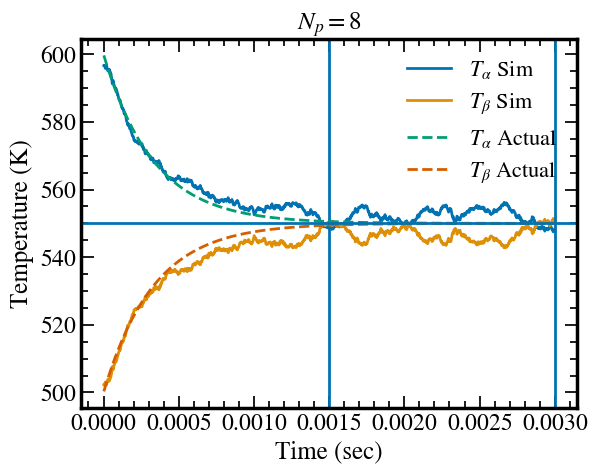

N_p 16: N_s 64


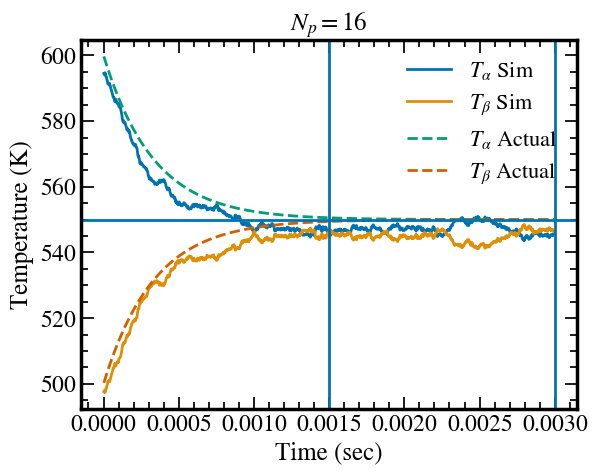

N_p 32: N_s 32


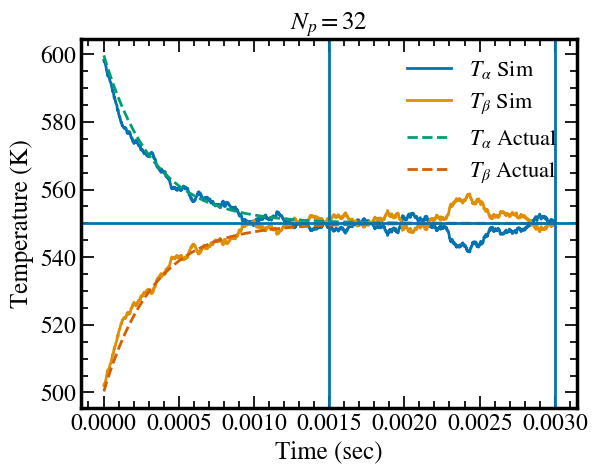

N_p 64: N_s 16


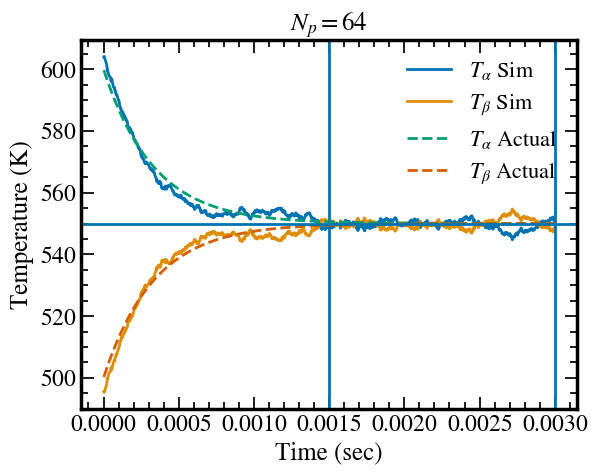

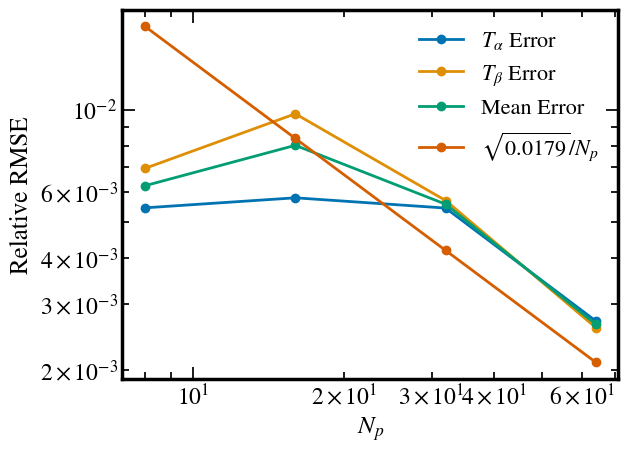

In [20]:
def collect_data(N_p, N_s, num_steps=1500):
  t_range = None
  T_a_vals = None
  T_b_vals = None
  for i in range(N_s):
    data = pd.read_csv(f"progress/{N_p:d}_ppe/run_{i:d}.csv")
    if i == 0:
      t_range = data["time"][1:].to_numpy()
      T_a_vals = data["T_alpha"][1:].to_numpy()
      T_b_vals = data["T_beta"][1:].to_numpy()

    else:
      if len(data["T_alpha"][1:].to_numpy()) != num_steps:
        continue
      T_a_vals = np.vstack((T_a_vals, data["T_alpha"][1:].to_numpy()))
      T_b_vals = np.vstack((T_b_vals, data["T_beta"][1:].to_numpy()))


  return t_range, T_a_vals, T_b_vals



N_p = 64
N_s = 10

alpha_errors = np.zeros(4, dtype=np.float32)
beta_errors  = np.zeros(4, dtype=np.float32)
mean_errors  = np.zeros(4, dtype=np.float32)
predicted_errors = np.zeros(4, dtype=np.float32)


ppe_vals = [2**i for i in range(3, 7)]
num_runs = [2**i for i in range(7, 3, -1)]

idx = int(1500 / 2)
end_idx = int((3000 - 1) / 2)
print(idx)
for j, (N_p, N_s) in enumerate(zip(ppe_vals, num_runs)):
  print(f"N_p {N_p:d}: N_s {N_s:d}")
  ppe_vals[j] = N_p
  t_range, T_a_vals, T_b_vals = collect_data(N_p, N_s)

  T_equib = ((T_a0 + T_b0) / 2).value

  T_a_mean = T_a_vals.mean(axis=0)
  T_b_mean = T_b_vals.mean(axis=0)

  T_a_equib_mean = T_a_mean[idx:end_idx].mean()
  T_b_equib_mean = T_a_mean[idx:end_idx].mean()

  T_a_true = T_alpha_true(t_range).value
  T_b_true = T_beta_true(t_range).value

  T_equib_actual = (T_a_mean + T_b_mean) / 2
  a_error = np.sqrt(((T_a_mean[idx:end_idx] - T_equib)**2 / T_equib**2).mean())
  b_error = np.sqrt(((T_b_mean[idx:end_idx] - T_equib)**2 / T_equib**2).mean())
  mean_error = np.sqrt((a_error**2 + b_error**2) / 2)
  predicted_error = 0.0179 / (N_p)
  alpha_errors[j] = a_error
  beta_errors[j] = b_error
  mean_errors[j] = mean_error
  predicted_errors[j] = predicted_error

  # print(f"Error Alpha Only : {a_error:0.4E}")
  # print(f"Error Beta Only  : {b_error:0.4E}")
  # print(f"Error Mean       : {(a_error + b_error) / 2:0.4E}")
  # print(f"Predicted Error  : {predicted_error:0.4E}")

  plt.figure()
  plt.title(f"$N_p = {N_p:d}$")
  plt.xlabel("Time (sec)")
  plt.ylabel("Temperature (K)")
  plt.plot(t_range, T_a_mean, label='$T_\\alpha$ Sim')
  plt.plot(t_range, T_b_mean, label='$T_\\beta$ Sim')
  plt.axvline(t_range[idx])
  plt.axvline(t_range[end_idx])
  plt.plot(t_range, T_a_true, '--', label='$T_\\alpha$ Actual')
  plt.plot(t_range, T_b_true, '--', label='$T_\\beta$ Actual')
  plt.axhline(T_equib)
  plt.legend(loc='upper right')
  plt.show()

plt.figure()
plt.loglog(ppe_vals, alpha_errors, '-o', label='$T_\\alpha$ Error')
plt.loglog(ppe_vals, beta_errors, '-o', label='$T_\\beta$ Error')
plt.loglog(ppe_vals, mean_errors, '-o', label='Mean Error')
plt.loglog(ppe_vals, np.sqrt(0.0179) / np.array(ppe_vals), '-o', label='$\\sqrt{0.0179}/N_p$')
plt.ylabel("Relative RMSE")
plt.xlabel("$N_p$")
plt.legend(loc='upper right')
plt.show()

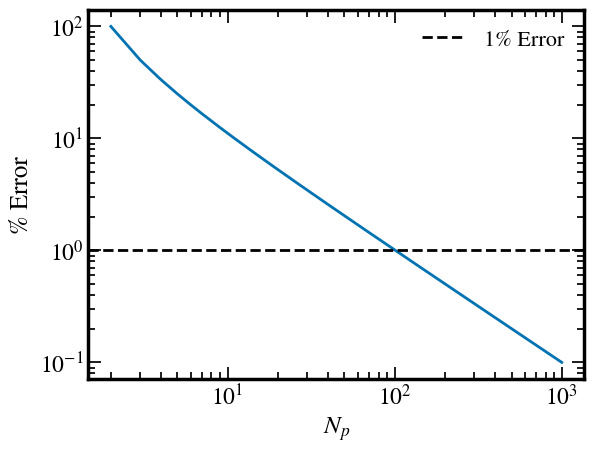

In [16]:
N = np.arange(2, 1000, 1)

actual = N * (N - 1)
wrong = N * N

error = (wrong - actual) / actual * 100
plt.figure()
plt.loglog(N, error)
plt.axhline(1, c='k', linestyle='dashed', label='1% Error')
plt.xlabel("$N_p$")
plt.ylabel("% Error")
plt.legend(loc='upper right')
plt.show()